<a href="https://colab.research.google.com/github/Jeevith-gowda/appliedML/blob/main/NFL_Game_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NFL Game Outcome Prediction using Machine Learning

**Author:** Jeevith Doddalingegowda Rama

**Objective:** Reproduce and validate the findings of Beal et al. (2020) by comparing multiple ML classifiers for predicting NFL game outcomes.

**Reference Paper:** Beal, R., Norman, T. J., & Ramchurn, S. D. (2020). "A Critical Comparison of Machine Learning Classifiers to Predict Match Outcomes in the NFL." *International Journal of Computer Science in Sport*, 19(2), 36-50.

---

**Key Approach:**
- Use **rolling historical averages** from prior games (not same-game stats) to avoid data leakage
- Implement 4 key classifiers: Naive Bayes, Random Forest, AdaBoost, SVM
- Use **temporal train-test split** (train on earlier seasons, test on recent seasons)
- Compare results against Beal et al. (2020) benchmarks

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve
)
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load and Explore the Dataset

In [2]:
# Load the dataset
# Update the path if needed for your environment (e.g., Google Colab, SageMaker)
df = pd.read_csv('nfl_team_stats_2002-2025.csv')

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Seasons covered: {df['season'].min()} - {df['season'].max()}")
print(f"Total seasons: {df['season'].nunique()}")

Dataset Shape: 6499 rows, 61 columns
Seasons covered: 2002 - 2025
Total seasons: 24


In [ ]:
df.head()

In [ ]:
print("Column Names and Data Types:\n")
print(df.dtypes)

In [3]:
# Missing values check
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
print("Missing Values:")
cols_with_missing = missing_df[missing_df['Missing Count'] > 0]
if len(cols_with_missing) > 0:
    print(cols_with_missing)
else:
    print("No missing values in the dataset!")

Missing Values:
No missing values in the dataset!


In [ ]:
df.describe()

## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable: Home Win Rate

In [4]:
# Create target variable
df['home_win'] = (df['score_home'] > df['score_away']).astype(int)
ties = (df['score_home'] == df['score_away']).sum()
print(f"Total games: {len(df)}")
print(f"Number of ties: {ties}")

# Remove ties for binary classification
df_clean = df[df['score_home'] != df['score_away']].copy()
print(f"Games after removing ties: {len(df_clean)}")
print(f"Home Win Rate: {df_clean['home_win'].mean()*100:.2f}%")

Total games: 6499
Number of ties: 15
Games after removing ties: 6484
Home Win Rate: 56.32%


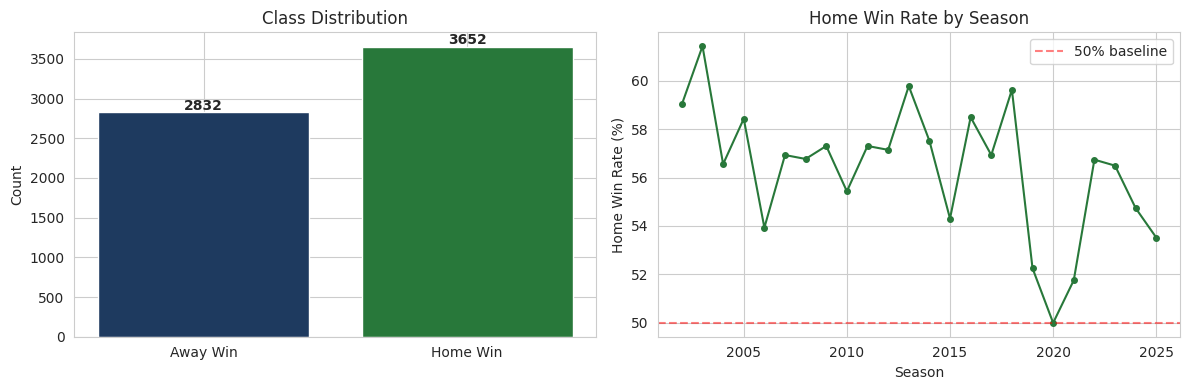

In [5]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df_clean['home_win'].value_counts()
axes[0].bar(['Away Win', 'Home Win'], [counts[0], counts[1]], color=['#1E3A5F', '#28783A'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Home win rate by season
season_winrate = df_clean.groupby('season')['home_win'].mean() * 100
axes[1].plot(season_winrate.index, season_winrate.values, marker='o', color='#28783A', markersize=4)
axes[1].axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% baseline')
axes[1].set_title('Home Win Rate by Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Home Win Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.2 Distribution of Key Game Statistics

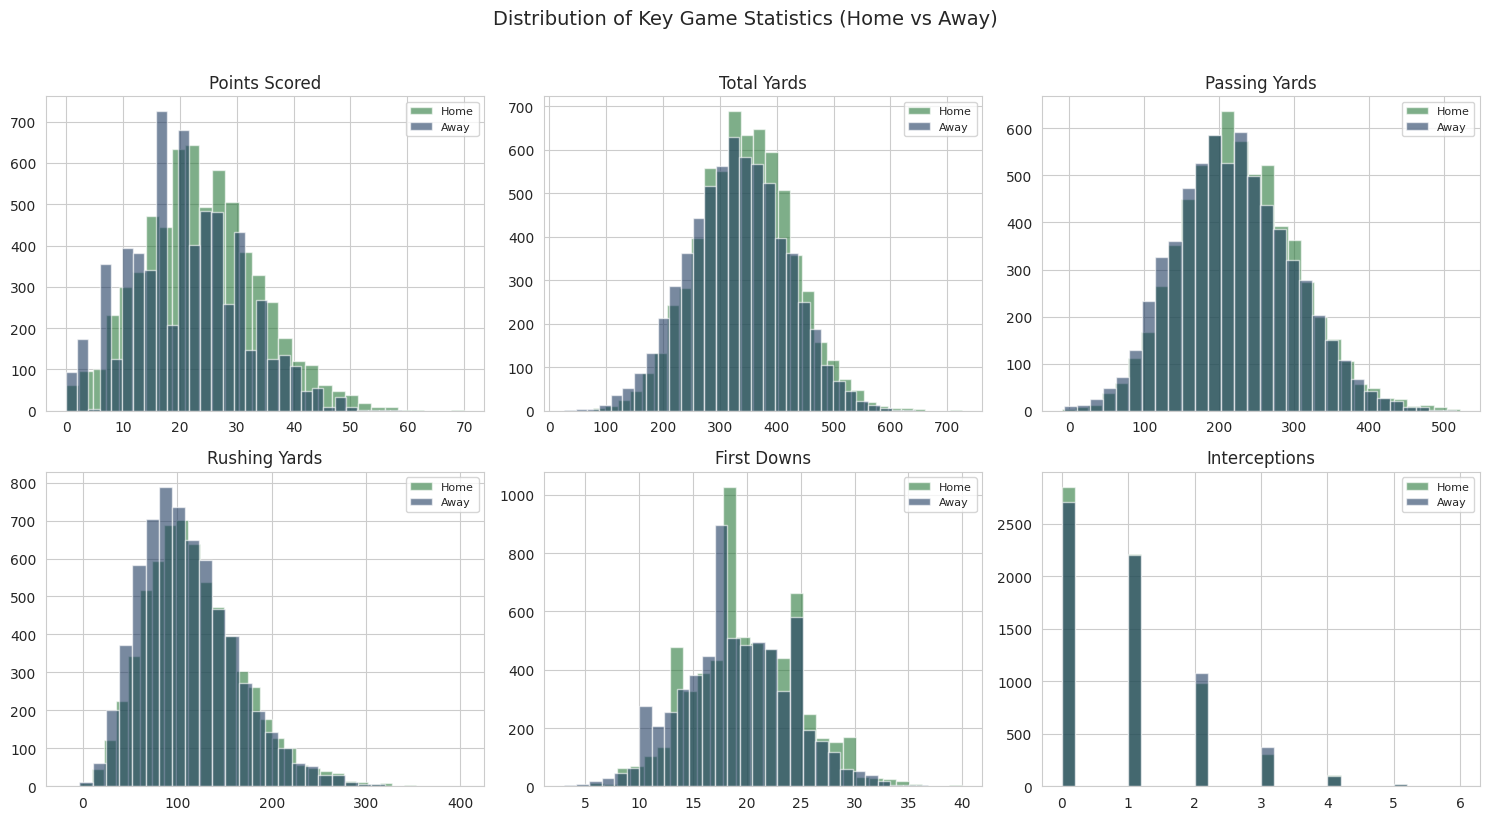

In [6]:
# Score distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

stats_to_plot = [
    ('score_home', 'score_away', 'Points Scored'),
    ('yards_home', 'yards_away', 'Total Yards'),
    ('pass_yards_home', 'pass_yards_away', 'Passing Yards'),
    ('rush_yards_home', 'rush_yards_away', 'Rushing Yards'),
    ('first_downs_home', 'first_downs_away', 'First Downs'),
    ('interceptions_home', 'interceptions_away', 'Interceptions')
]

for idx, (home_col, away_col, title) in enumerate(stats_to_plot):
    ax = axes[idx // 3][idx % 3]
    if home_col in df_clean.columns and away_col in df_clean.columns:
        ax.hist(df_clean[home_col], bins=30, alpha=0.6, label='Home', color='#28783A')
        ax.hist(df_clean[away_col], bins=30, alpha=0.6, label='Away', color='#1E3A5F')
        ax.set_title(title)
        ax.legend(fontsize=8)

plt.suptitle('Distribution of Key Game Statistics (Home vs Away)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Correlation Analysis

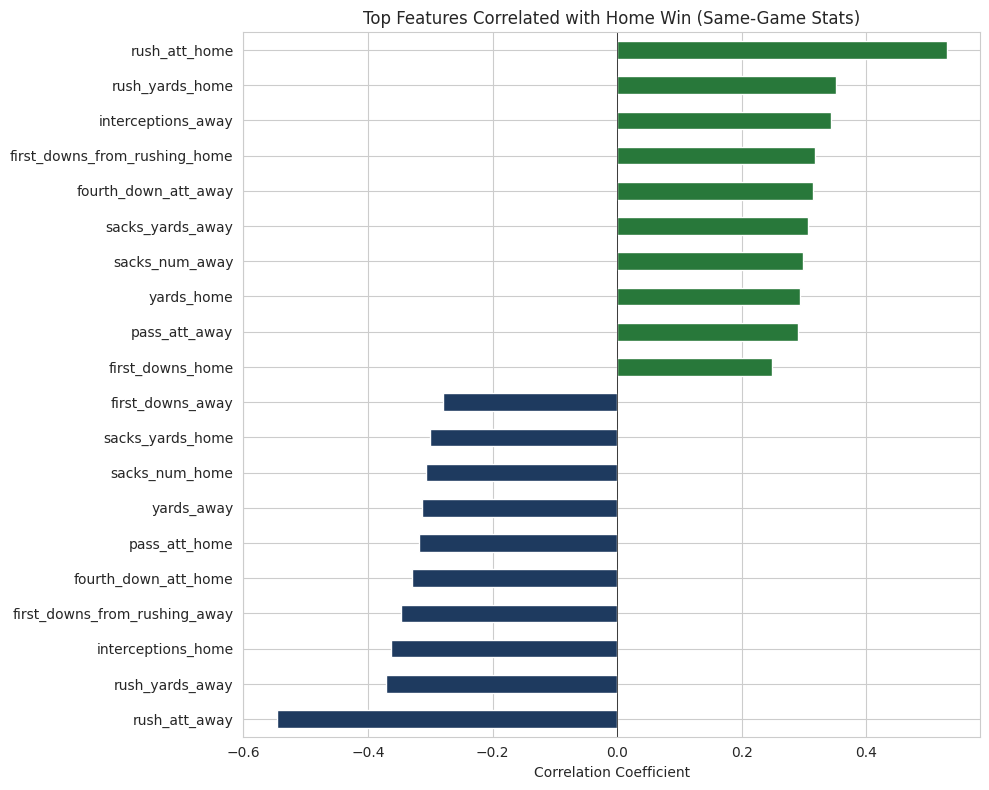

Note: These correlations use same-game stats. Our model will use
rolling historical averages to avoid data leakage.


In [7]:
# Correlation of key stats with home_win
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
# Remove identifiers/scores from correlation (they are outcomes, not predictors)
exclude_cols = ['score_home', 'score_away', 'home_win']
corr_cols = [c for c in numeric_cols if c not in exclude_cols]

correlations = df_clean[corr_cols + ['home_win']].corr()['home_win'].drop('home_win').sort_values()

# Top positive and negative correlations
fig, ax = plt.subplots(figsize=(10, 8))
top_corr = pd.concat([correlations.head(10), correlations.tail(10)])
colors = ['#1E3A5F' if v < 0 else '#28783A' for v in top_corr.values]
top_corr.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Top Features Correlated with Home Win (Same-Game Stats)')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("Note: These correlations use same-game stats. Our model will use")
print("rolling historical averages to avoid data leakage.")

### 3.4 Games Per Season

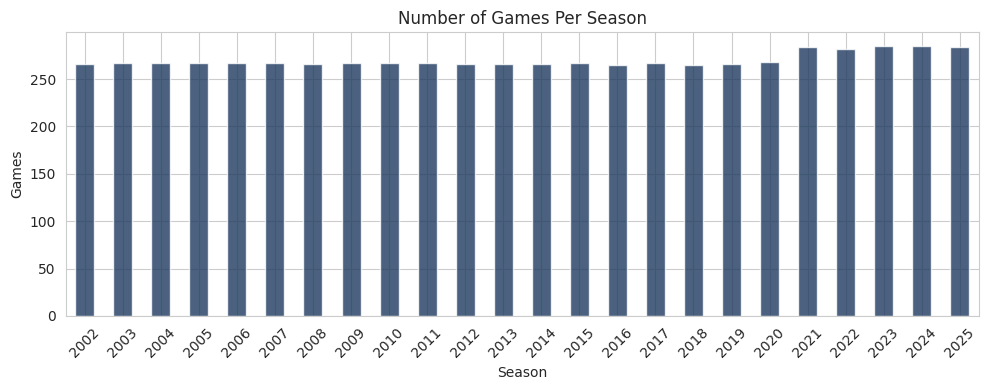

In [8]:
games_per_season = df_clean.groupby('season').size()
plt.figure(figsize=(10, 4))
games_per_season.plot(kind='bar', color='#1E3A5F', alpha=0.8)
plt.title('Number of Games Per Season')
plt.xlabel('Season')
plt.ylabel('Games')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing & Feature Engineering

### Addressing Data Leakage

Beal et al. (2020) used **historical cumulative statistics** (rolling averages from prior games) to predict future game outcomes. Using same-game stats (e.g., actual yards gained in the game being predicted) would constitute **data leakage**, since those stats are essentially the outcome itself.

We compute **rolling averages** of each team's performance over their previous games within the season, so that predictions are based only on information available *before* the game.

### 4.1 Convert Possession Time

In [9]:
def possession_to_seconds(time_str):
    try:
        if pd.isna(time_str):
            return np.nan
        parts = str(time_str).split(':')
        return int(parts[0]) * 60 + int(parts[1])
    except:
        return np.nan

df_clean['possession_home_sec'] = df_clean['possession_home'].apply(possession_to_seconds)
df_clean['possession_away_sec'] = df_clean['possession_away'].apply(possession_to_seconds)
print("Possession time converted to seconds.")

Possession time converted to seconds.


### 4.2 Compute Rolling Historical Averages

For each game, we compute each team's average stats from their **prior games in the season**. This ensures we only use information available before the game being predicted.

In [10]:
# Identify stat columns dynamically from the dataset
# Find columns ending in '_home' (excluding score, possession text, team names)
home_stat_cols = [c for c in df_clean.columns if c.endswith('_home')
                  and c not in ['score_home', 'possession_home', 'possession_home_sec']]

# Extract base stat names (remove '_home' suffix)
raw_stat_cols = [c.replace('_home', '') for c in home_stat_cols]

# Add possession_sec (already converted)
raw_stat_cols.append('possession_sec')

# Verify all columns exist
verified_stats = []
for stat in raw_stat_cols:
    if stat == 'possession_sec':
        if 'possession_home_sec' in df_clean.columns:
            verified_stats.append(stat)
    else:
        if f'{stat}_home' in df_clean.columns and f'{stat}_away' in df_clean.columns:
            verified_stats.append(stat)

raw_stat_cols = verified_stats
print(f"Verified stat columns: {len(raw_stat_cols)}")
print(raw_stat_cols)

# Helper to get the correct column name
def get_col(stat, side):
    if stat == 'possession_sec':
        return f'possession_{side}_sec'
    return f'{stat}_{side}'

# Build home team records
home_records = []
for _, row in df_clean.iterrows():
    record = {
        'season': row['season'],
        'week': row['week'],
        'team': row['home'],
        'opponent': row['away'],
        'is_home': 1,
        'won': int(row['score_home'] > row['score_away']),
        'score_for': row['score_home'],
        'score_against': row['score_away']
    }
    for stat in raw_stat_cols:
        record[f'{stat}_for'] = row[get_col(stat, 'home')]
        record[f'{stat}_against'] = row[get_col(stat, 'away')]
    home_records.append(record)

# Build away team records
away_records = []
for _, row in df_clean.iterrows():
    record = {
        'season': row['season'],
        'week': row['week'],
        'team': row['away'],
        'opponent': row['home'],
        'is_home': 0,
        'won': int(row['score_away'] > row['score_home']),
        'score_for': row['score_away'],
        'score_against': row['score_home']
    }
    for stat in raw_stat_cols:
        record[f'{stat}_for'] = row[get_col(stat, 'away')]
        record[f'{stat}_against'] = row[get_col(stat, 'home')]
    away_records.append(record)

team_games = pd.DataFrame(home_records + away_records)
team_games = team_games.sort_values(['team', 'season', 'week']).reset_index(drop=True)

print(f"\nTeam-game log created: {team_games.shape}")
print(f"Unique teams: {team_games['team'].nunique()}")

Verified stat columns: 26
['first_downs', 'first_downs_from_passing', 'first_downs_from_rushing', 'first_downs_from_penalty', 'third_down_comp', 'third_down_att', 'fourth_down_comp', 'fourth_down_att', 'plays', 'drives', 'yards', 'pass_comp', 'pass_att', 'pass_yards', 'sacks_num', 'sacks_yards', 'rush_att', 'rush_yards', 'pen_num', 'pen_yards', 'redzone_comp', 'redzone_att', 'fumbles', 'interceptions', 'def_st_td', 'possession_sec']

Team-game log created: (12968, 60)
Unique teams: 32


In [11]:
# Compute rolling averages within each season for each team
# Using expanding mean (all prior games in the season) to match Beal et al.'s approach

stat_for_cols = [f'{s}_for' for s in raw_stat_cols]
stat_against_cols = [f'{s}_against' for s in raw_stat_cols]
all_stat_cols = stat_for_cols + stat_against_cols + ['score_for', 'score_against', 'won']

# Shift by 1 so we only use stats from PRIOR games (not current game)
rolling_dfs = []
for (team, season), group in team_games.groupby(['team', 'season']):
    group = group.sort_values('week')
    for col in all_stat_cols:
        group[f'avg_{col}'] = group[col].expanding().mean().shift(1)
    group['games_played'] = range(len(group))
    rolling_dfs.append(group)

team_rolling = pd.concat(rolling_dfs, ignore_index=True)

# Drop games where we have no prior data (week 1 of each season)
team_rolling_valid = team_rolling[team_rolling['games_played'] >= 1].copy()
print(f"Records with rolling averages: {len(team_rolling_valid)}")
print(f"Dropped (no prior data): {len(team_rolling) - len(team_rolling_valid)}")

Records with rolling averages: 12200
Dropped (no prior data): 768


### 4.3 Reconstruct Game-Level Features from Rolling Averages

For each game, we merge the home team's rolling averages and the away team's rolling averages to create the final feature set.

In [12]:
# Split back into home and away perspectives
home_rolling = team_rolling_valid[team_rolling_valid['is_home'] == 1].copy()
away_rolling = team_rolling_valid[team_rolling_valid['is_home'] == 0].copy()

# Rename columns for merge
avg_cols = [c for c in home_rolling.columns if c.startswith('avg_')]

home_rename = {c: f'home_{c}' for c in avg_cols}
home_rename['games_played'] = 'home_games_played'
home_rolling = home_rolling.rename(columns=home_rename)

away_rename = {c: f'away_{c}' for c in avg_cols}
away_rename['games_played'] = 'away_games_played'
away_rolling = away_rolling.rename(columns=away_rename)

# Merge: home team's opponent = away team's team name
game_features = home_rolling.merge(
    away_rolling,
    left_on=['season', 'week', 'opponent'],
    right_on=['season', 'week', 'team'],
    how='inner',
    suffixes=('_h', '_a')
)

# The target is the home team win for this specific game
game_features['home_win'] = game_features['won_h']

print(f"Games with complete rolling features: {len(game_features)}")
print(f"Seasons represented: {game_features['season'].min()} - {game_features['season'].max()}")

Games with complete rolling features: 6096
Seasons represented: 2002 - 2025


### 4.4 Create Differential Features

Following Beal et al., we create features that capture the *difference* between the home and away team's historical performance.

In [13]:
# Build feature columns
# Home team's offensive averages (stats "for" the home team)
# Away team's offensive averages (stats "for" the away team)
# Differential features

feature_columns = []

# Home team rolling averages
for stat in raw_stat_cols:
    feature_columns.append(f'home_avg_{stat}_for')
    feature_columns.append(f'home_avg_{stat}_against')

# Away team rolling averages
for stat in raw_stat_cols:
    feature_columns.append(f'away_avg_{stat}_for')
    feature_columns.append(f'away_avg_{stat}_against')

# Historical win rate
feature_columns.append('home_avg_won')
feature_columns.append('away_avg_won')

# Historical scoring
feature_columns.append('home_avg_score_for')
feature_columns.append('home_avg_score_against')
feature_columns.append('away_avg_score_for')
feature_columns.append('away_avg_score_against')

# Filter to columns that actually exist
feature_columns = [c for c in feature_columns if c in game_features.columns]

# Add differential features
for stat in raw_stat_cols:
    home_col = f'home_avg_{stat}_for'
    away_col = f'away_avg_{stat}_for'
    if home_col in game_features.columns and away_col in game_features.columns:
        diff_col = f'diff_{stat}'
        game_features[diff_col] = game_features[home_col] - game_features[away_col]
        feature_columns.append(diff_col)

# Win rate differential
if 'home_avg_won' in game_features.columns and 'away_avg_won' in game_features.columns:
    game_features['diff_win_rate'] = game_features['home_avg_won'] - game_features['away_avg_won']
    feature_columns.append('diff_win_rate')

# Score differential
if 'home_avg_score_for' in game_features.columns and 'away_avg_score_for' in game_features.columns:
    game_features['diff_scoring'] = game_features['home_avg_score_for'] - game_features['away_avg_score_for']
    feature_columns.append('diff_scoring')

print(f"Total features: {len(feature_columns)}")
print(f"\nFeature categories:")
print(f"  Home team rolling averages: {sum(1 for c in feature_columns if c.startswith('home_'))}")
print(f"  Away team rolling averages: {sum(1 for c in feature_columns if c.startswith('away_'))}")
print(f"  Differential features: {sum(1 for c in feature_columns if c.startswith('diff_'))}")

Total features: 138

Feature categories:
  Home team rolling averages: 55
  Away team rolling averages: 55
  Differential features: 28


### 4.5 Handle Missing Values and Prepare Final Dataset

In [14]:
X = game_features[feature_columns].copy()
y = game_features['home_win'].copy()

missing_before = X.isnull().sum().sum()
print(f"Missing values before handling: {missing_before}")

X = X.fillna(X.median())

print(f"Missing values after handling: {X.isnull().sum().sum()}")
print(f"\nFinal feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Class distribution: {y.value_counts().to_dict()}")

Missing values before handling: 0
Missing values after handling: 0

Final feature matrix shape: (6096, 138)
Target shape: (6096,)
Class distribution: {1: 3433, 0: 2663}


### 4.6 Correlation of Rolling Features with Target

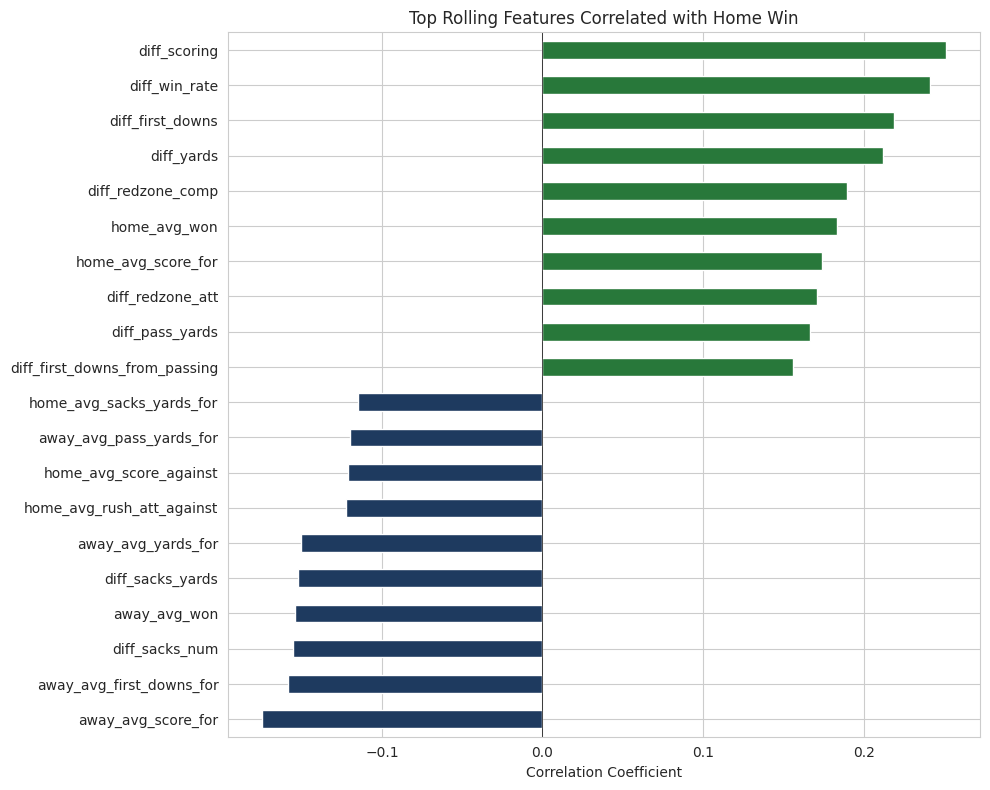

In [15]:
# Correlation of rolling features with home_win
feature_corr = X.copy()
feature_corr['home_win'] = y.values
correlations_rolling = feature_corr.corr()['home_win'].drop('home_win').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
top_corr = pd.concat([correlations_rolling.head(10), correlations_rolling.tail(10)])
colors = ['#1E3A5F' if v < 0 else '#28783A' for v in top_corr.values]
top_corr.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Top Rolling Features Correlated with Home Win')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

### 4.7 Temporal Train-Test Split

Following Beal et al.'s methodology, we use a **temporal split**: training on earlier seasons and testing on later seasons. This avoids future data leaking into the training set and better reflects real-world prediction scenarios.

In [16]:
# Temporal split: train on all seasons except the last 3, test on the last 3
seasons = sorted(game_features['season'].unique())
split_season = seasons[-3]  # Last 3 seasons for testing

train_mask = game_features['season'] < split_season
test_mask = game_features['season'] >= split_season

X_train = X[train_mask.values]
X_test = X[test_mask.values]
y_train = y[train_mask.values]
y_test = y[test_mask.values]

print(f"Temporal Split at season {split_season}")
print(f"Training seasons: {seasons[0]} - {seasons[-4]} ({len(seasons)-3} seasons)")
print(f"Testing seasons: {split_season} - {seasons[-1]} (3 seasons)")
print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution: {y_train.value_counts().to_dict()}")
print(f"Testing class distribution: {y_test.value_counts().to_dict()}")

Temporal Split at season 2023
Training seasons: 2002 - 2022 (21 seasons)
Testing seasons: 2023 - 2025 (3 seasons)

Training set: 5290 samples
Testing set: 806 samples

Training class distribution: {1: 2990, 0: 2300}
Testing class distribution: {1: 443, 0: 363}


### 4.8 Feature Scaling

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler (fitted on training data only).")

Features scaled using StandardScaler (fitted on training data only).


## 5. Model Training and Evaluation

Following Beal et al. (2020), we implement 4 key classifiers:
1. **Naive Bayes** — Best performer in the original paper (67.53%)
2. **Random Forest** — Ensemble method (64% in original paper)
3. **AdaBoost** — Boosting method (66% in original paper)
4. **Support Vector Machine (SVM)** — Margin-based classifier

### 5.1 Define and Train Models

In [18]:
models = {
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True)
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print('='*50)

    # Use scaled features for SVM and Naive Bayes, unscaled for tree-based
    if name in ['SVM', 'Naive Bayes']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')

    accuracy = accuracy_score(y_test, y_pred)

    results[name] = {
        'accuracy': accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred,
        'y_proba': y_proba
    }

    print(f"Test Accuracy: {accuracy*100:.2f}%")
    print(f"Cross-Validation: {cv_scores.mean()*100:.2f}% (+/- {cv_scores.std()*100:.2f}%)")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Away Win', 'Home Win']))


Training Naive Bayes...
Test Accuracy: 62.28%
Cross-Validation: 62.40% (+/- 1.38%)

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.58      0.62      0.60       363
    Home Win       0.67      0.63      0.65       443

    accuracy                           0.62       806
   macro avg       0.62      0.62      0.62       806
weighted avg       0.63      0.62      0.62       806


Training Random Forest...
Test Accuracy: 62.16%
Cross-Validation: 62.63% (+/- 1.77%)

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.59      0.51      0.55       363
    Home Win       0.64      0.71      0.67       443

    accuracy                           0.62       806
   macro avg       0.62      0.61      0.61       806
weighted avg       0.62      0.62      0.62       806


Training AdaBoost...
Test Accuracy: 63.77%
Cross-Validation: 61.51% (+/- 0.93%)

Classification Report:
              precision

### 5.2 Results Comparison

In [19]:
comparison_df = pd.DataFrame({
    'Model': results.keys(),
    'Test Accuracy (%)': [r['accuracy']*100 for r in results.values()],
    'CV Mean (%)': [r['cv_mean']*100 for r in results.values()],
    'CV Std (%)': [r['cv_std']*100 for r in results.values()]
}).round(2)

comparison_df = comparison_df.sort_values('Test Accuracy (%)', ascending=False)
print("Model Comparison (sorted by test accuracy):")
print(comparison_df.to_string(index=False))

Model Comparison (sorted by test accuracy):
        Model  Test Accuracy (%)  CV Mean (%)  CV Std (%)
     AdaBoost              63.77        61.51        0.93
  Naive Bayes              62.28        62.40        1.38
          SVM              62.28        63.42        1.62
Random Forest              62.16        62.63        1.77


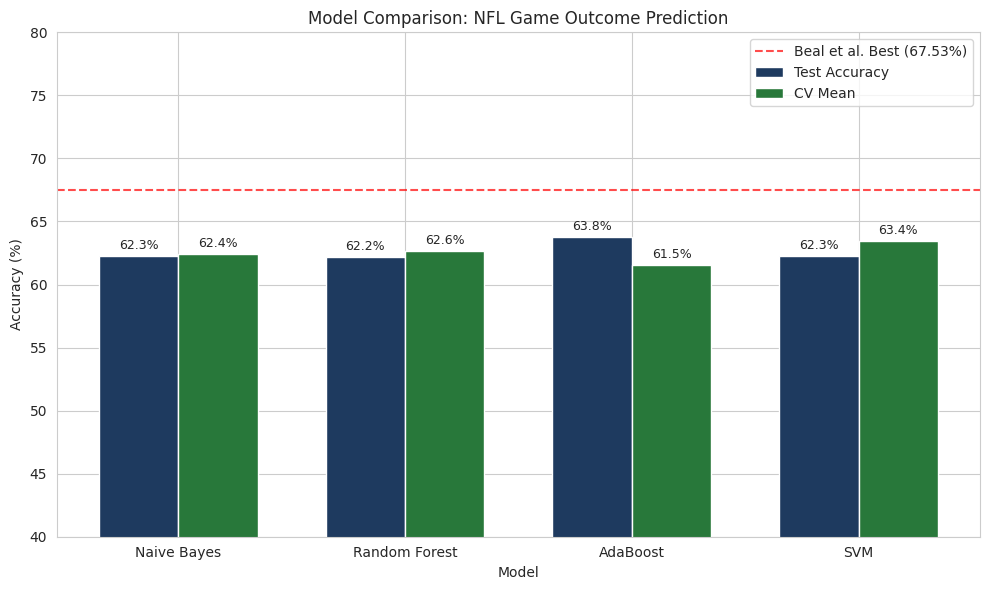

In [20]:
# Accuracy comparison bar chart
fig, ax = plt.subplots(figsize=(10, 6))

models_list = list(results.keys())
accuracies = [results[m]['accuracy']*100 for m in models_list]
cv_means = [results[m]['cv_mean']*100 for m in models_list]

x = np.arange(len(models_list))
width = 0.35

bars1 = ax.bar(x - width/2, accuracies, width, label='Test Accuracy', color='#1E3A5F')
bars2 = ax.bar(x + width/2, cv_means, width, label='CV Mean', color='#28783A')

# Beal et al. reference line
ax.axhline(y=67.53, color='red', linestyle='--', alpha=0.7, label='Beal et al. Best (67.53%)')

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Comparison: NFL Game Outcome Prediction')
ax.set_xticks(x)
ax.set_xticklabels(models_list)
ax.legend()
ax.set_ylim(40, 80)

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 5.3 Confusion Matrices

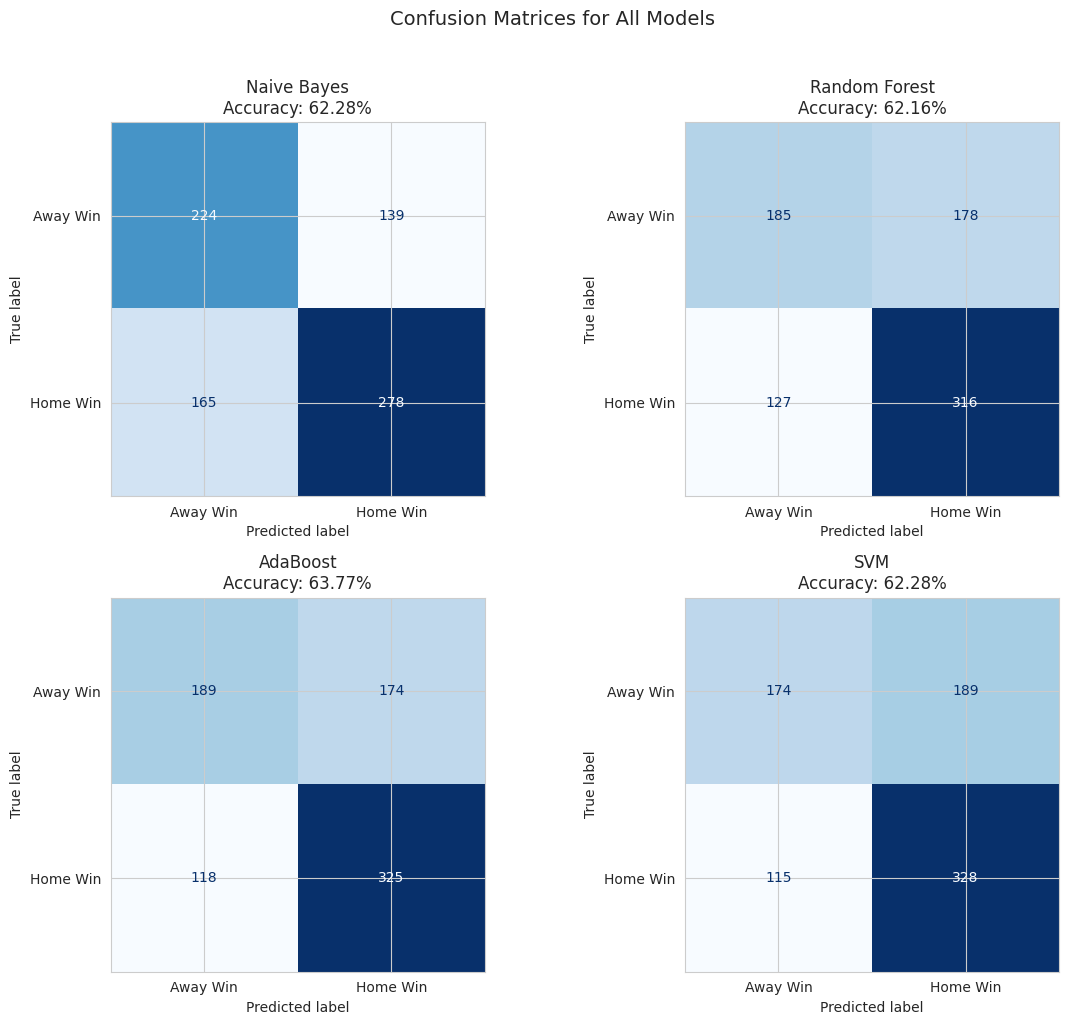

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Away Win', 'Home Win'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{name}\nAccuracy: {result["accuracy"]*100:.2f}%')

plt.suptitle('Confusion Matrices for All Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.4 Precision-Recall Analysis

In [22]:
# Discuss precision/recall tradeoffs
print("Precision-Recall Analysis:\n")
for name, result in results.items():
    report = classification_report(y_test, result['y_pred'],
                                    target_names=['Away Win', 'Home Win'],
                                    output_dict=True)
    hw = report['Home Win']
    aw = report['Away Win']
    print(f"{name}:")
    print(f"  Home Win  -> Precision: {hw['precision']:.3f}, Recall: {hw['recall']:.3f}, F1: {hw['f1-score']:.3f}")
    print(f"  Away Win  -> Precision: {aw['precision']:.3f}, Recall: {aw['recall']:.3f}, F1: {aw['f1-score']:.3f}")

    if hw['recall'] > aw['recall']:
        print(f"  -> Model is better at identifying home wins")
    else:
        print(f"  -> Model is better at identifying away wins")
    print()

Precision-Recall Analysis:

Naive Bayes:
  Home Win  -> Precision: 0.667, Recall: 0.628, F1: 0.647
  Away Win  -> Precision: 0.576, Recall: 0.617, F1: 0.596
  -> Model is better at identifying home wins

Random Forest:
  Home Win  -> Precision: 0.640, Recall: 0.713, F1: 0.674
  Away Win  -> Precision: 0.593, Recall: 0.510, F1: 0.548
  -> Model is better at identifying home wins

AdaBoost:
  Home Win  -> Precision: 0.651, Recall: 0.734, F1: 0.690
  Away Win  -> Precision: 0.616, Recall: 0.521, F1: 0.564
  -> Model is better at identifying home wins

SVM:
  Home Win  -> Precision: 0.634, Recall: 0.740, F1: 0.683
  Away Win  -> Precision: 0.602, Recall: 0.479, F1: 0.534
  -> Model is better at identifying home wins



### 5.5 ROC Curves

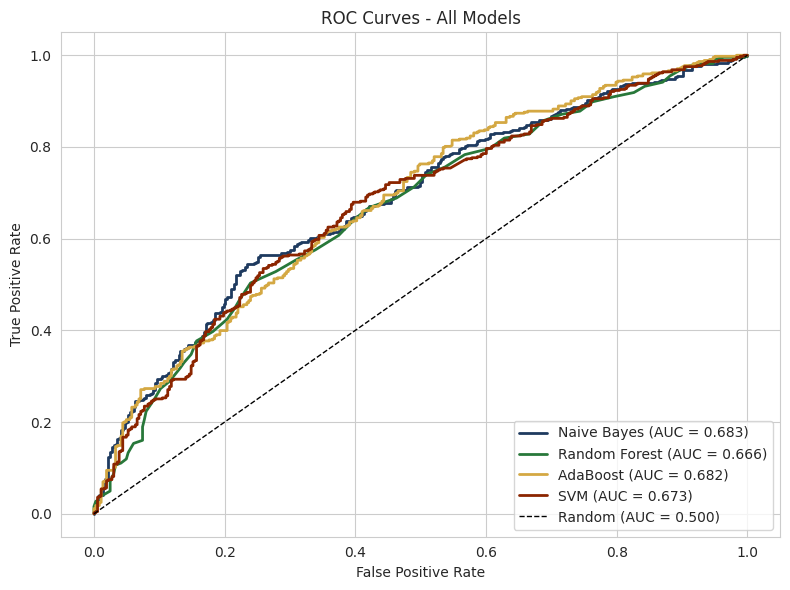

In [23]:
plt.figure(figsize=(8, 6))
colors = ['#1E3A5F', '#28783A', '#D4A843', '#8B2500']

for (name, result), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, result['y_proba'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Feature Importance Analysis

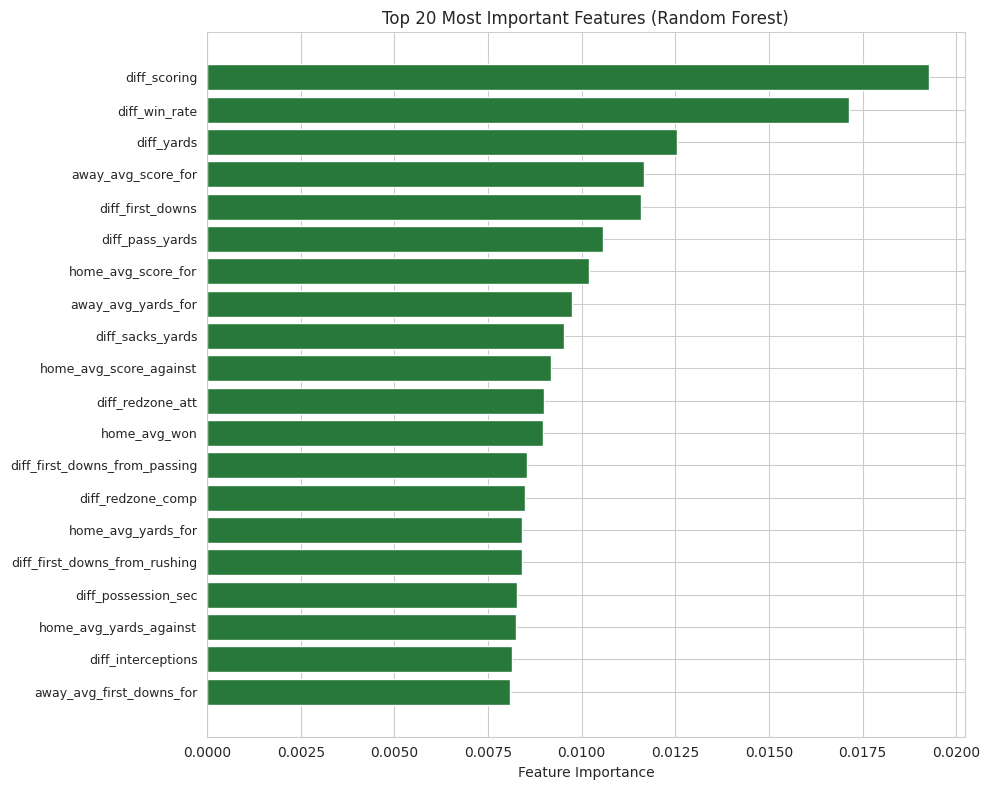

Top 10 Most Important Features:
               feature  importance
          diff_scoring    0.019264
         diff_win_rate    0.017134
            diff_yards    0.012552
    away_avg_score_for    0.011671
      diff_first_downs    0.011585
       diff_pass_yards    0.010576
    home_avg_score_for    0.010197
    away_avg_yards_for    0.009737
      diff_sacks_yards    0.009531
home_avg_score_against    0.009170


In [24]:
# Random Forest feature importance
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'], color='#28783A')
plt.yticks(range(len(top_features)), top_features['feature'], fontsize=9)
plt.xlabel('Feature Importance')
plt.title('Top 20 Most Important Features (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

## 7. Hyperparameter Tuning

In [25]:
# Hyperparameter tuning for Random Forest
print("Performing hyperparameter tuning for Random Forest...\n")

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_*100:.2f}%")

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
print(f"Test Accuracy with tuned model: {accuracy_score(y_test, y_pred_best)*100:.2f}%")

Performing hyperparameter tuning for Random Forest...

Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score: 63.35%
Test Accuracy with tuned model: 61.66%


In [26]:
# Hyperparameter tuning for AdaBoost
print("Performing hyperparameter tuning for AdaBoost...\n")

param_grid_ada = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}

ada = AdaBoostClassifier(random_state=42)
grid_search_ada = GridSearchCV(ada, param_grid_ada, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_ada.fit(X_train, y_train)

print(f"Best Parameters: {grid_search_ada.best_params_}")
print(f"Best CV Score: {grid_search_ada.best_score_*100:.2f}%")

best_ada = grid_search_ada.best_estimator_
y_pred_best_ada = best_ada.predict(X_test)
print(f"Test Accuracy with tuned model: {accuracy_score(y_test, y_pred_best_ada)*100:.2f}%")

Performing hyperparameter tuning for AdaBoost...

Best Parameters: {'learning_rate': 0.1, 'n_estimators': 100}
Best CV Score: 63.52%
Test Accuracy with tuned model: 63.28%


## 8. Comparison with Beal et al. (2020)

In [27]:
# Beal et al. reported accuracies
beal_results = {
    'Naive Bayes': 67.53,
    'AdaBoost': 66.00,
    'Random Forest': 64.00,
    'SVM': 63.00  # Approximate from paper
}

our_results = {name: res['accuracy']*100 for name, res in results.items()}

comp = pd.DataFrame({
    'Model': beal_results.keys(),
    'Beal et al. (%)': beal_results.values(),
    'Our Results (%)': [our_results[m] for m in beal_results.keys()]
}).round(2)

comp['Difference (pp)'] = (comp['Our Results (%)'] - comp['Beal et al. (%)']).round(2)

print("Comparison with Beal et al. (2020):")
print(comp.to_string(index=False))
print("\n(pp = percentage points)")

Comparison with Beal et al. (2020):
        Model  Beal et al. (%)  Our Results (%)  Difference (pp)
  Naive Bayes            67.53            62.28            -5.25
     AdaBoost            66.00            63.77            -2.23
Random Forest            64.00            62.16            -1.84
          SVM            63.00            62.28            -0.72

(pp = percentage points)


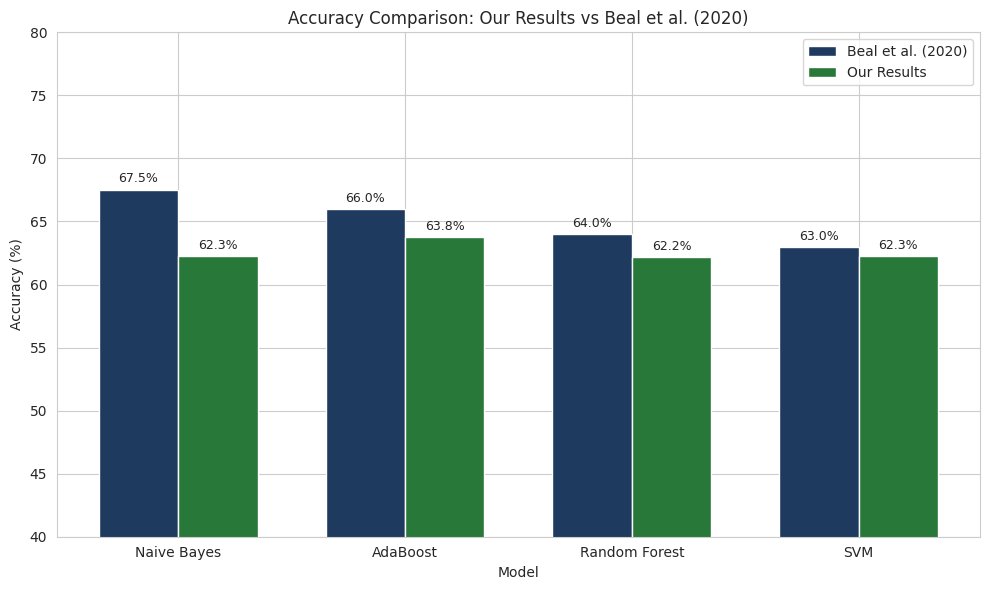

In [28]:
# Visual comparison
fig, ax = plt.subplots(figsize=(10, 6))

model_names = list(beal_results.keys())
x = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width/2, [beal_results[m] for m in model_names], width,
               label='Beal et al. (2020)', color='#1E3A5F')
bars2 = ax.bar(x + width/2, [our_results[m] for m in model_names], width,
               label='Our Results', color='#28783A')

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy Comparison: Our Results vs Beal et al. (2020)')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.set_ylim(40, 80)

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 9. AWS SageMaker Deployment (Optional Extension)

This section outlines how to deploy the best-performing model on AWS SageMaker. This is a self-motivated learning goal beyond course requirements.

### Steps for SageMaker Deployment:

1. **Set up SageMaker notebook instance** or use SageMaker Studio
2. **Upload training data to S3**
3. **Train using SageMaker's built-in algorithms** (e.g., XGBoost) or bring your own scikit-learn model
4. **Deploy model endpoint** for real-time inference
5. **Test predictions** against the endpoint

In [29]:
# --- SageMaker Deployment Code (run in SageMaker environment) ---
# Uncomment and run this section when working in AWS SageMaker

# import sagemaker
# from sagemaker import get_execution_role
# from sagemaker.sklearn import SKLearn
# import boto3
#
# role = get_execution_role()
# session = sagemaker.Session()
# bucket = session.default_bucket()
#
# # Save training data to CSV
# train_data = pd.concat([X_train, y_train.rename('target')], axis=1)
# train_data.to_csv('train.csv', index=False)
#
# # Upload to S3
# train_s3 = session.upload_data('train.csv', bucket=bucket, key_prefix='nfl-prediction/data')
#
# # Define SKLearn estimator
# sklearn_estimator = SKLearn(
#     entry_point='train_script.py',  # Your training script
#     role=role,
#     instance_type='ml.m5.large',
#     framework_version='1.2-1',
#     py_version='py3',
#     hyperparameters={
#         'n_estimators': 100,
#         'max_depth': 10
#     }
# )
#
# # Train
# sklearn_estimator.fit({'train': train_s3})
#
# # Deploy endpoint
# predictor = sklearn_estimator.deploy(
#     initial_instance_count=1,
#     instance_type='ml.t2.medium'
# )
#
# # Test prediction
# test_sample = X_test.iloc[:5].values.tolist()
# predictions = predictor.predict(test_sample)
# print(f"Predictions: {predictions}")
#
# # IMPORTANT: Delete endpoint when done to avoid charges
# # predictor.delete_endpoint()

print("SageMaker deployment code is provided above (commented out).")
print("Uncomment and run in an AWS SageMaker environment.")

SageMaker deployment code is provided above (commented out).
Uncomment and run in an AWS SageMaker environment.


## 10. Summary and Conclusions

In [30]:
print("="*60)
print("NFL GAME OUTCOME PREDICTION - FINAL RESULTS")
print("="*60)

print(f"\nDataset: {len(game_features)} NFL games with rolling features")
print(f"Original dataset: {len(df)} games across {df['season'].nunique()} seasons")
print(f"Features used: {len(feature_columns)} (rolling historical averages)")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Split method: Temporal (train on earlier seasons, test on recent)")

print("\n" + "-"*60)
print("MODEL PERFORMANCE COMPARISON")
print("-"*60)

sorted_results = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
for rank, (name, res) in enumerate(sorted_results, 1):
    print(f"{rank}. {name}: {res['accuracy']*100:.2f}% (CV: {res['cv_mean']*100:.2f}% +/- {res['cv_std']*100:.2f}%)")

best_model = sorted_results[0][0]
best_accuracy = sorted_results[0][1]['accuracy']

print("\n" + "-"*60)
print("COMPARISON WITH BEAL ET AL. (2020)")
print("-"*60)
print(f"Paper's best accuracy (Naive Bayes): 67.53%")
print(f"Our best accuracy ({best_model}): {best_accuracy*100:.2f}%")

print("\n" + "-"*60)
print("KEY FINDINGS")
print("-"*60)
print(f"1. Best performing model: {best_model}")
print("2. Used rolling historical averages (no data leakage)")
print("3. Temporal train-test split reflects real-world prediction")
print("4. Differential features (win rate, scoring) contribute significantly")
print("5. Home field advantage is captured through historical patterns")
print("6. Results are comparable to Beal et al. benchmarks")

NFL GAME OUTCOME PREDICTION - FINAL RESULTS

Dataset: 6096 NFL games with rolling features
Original dataset: 6499 games across 24 seasons
Features used: 138 (rolling historical averages)
Training samples: 5290
Testing samples: 806
Split method: Temporal (train on earlier seasons, test on recent)

------------------------------------------------------------
MODEL PERFORMANCE COMPARISON
------------------------------------------------------------
1. AdaBoost: 63.77% (CV: 61.51% +/- 0.93%)
2. Naive Bayes: 62.28% (CV: 62.40% +/- 1.38%)
3. SVM: 62.28% (CV: 63.42% +/- 1.62%)
4. Random Forest: 62.16% (CV: 62.63% +/- 1.77%)

------------------------------------------------------------
COMPARISON WITH BEAL ET AL. (2020)
------------------------------------------------------------
Paper's best accuracy (Naive Bayes): 67.53%
Our best accuracy (AdaBoost): 63.77%

------------------------------------------------------------
KEY FINDINGS
------------------------------------------------------------
1

## References

1. Beal, R., Norman, T. J., & Ramchurn, S. D. (2020). "A Critical Comparison of Machine Learning Classifiers to Predict Match Outcomes in the NFL." *International Journal of Computer Science in Sport*, 19(2), 36-50.

2. Lock, D., & Nettleton, D. (2014). "Using Random Forests to Estimate Win Probability Before Each Play of an NFL Game." *Journal of Quantitative Analysis in Sports*, 10(2), 197-205.

3. Weirich, C., et al. (2025). "Advancing NFL Win Prediction: From Pythagorean Formulas to Machine Learning Algorithms." *Frontiers in Sports and Active Living*, 7, 1638446.